In [1]:
# Base packages
import numpy as np
import matplotlib.pyplot as plt
import os
import copy

# I/O
import glob
from skimage import io
from PIL import Image
import h5py
import json
import pickle

# Pytorch
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import ToTensor

# Data Augmentation
import imgaug as ia
import imgaug.augmenters as iaa
from imgaug.augmentables.segmaps import SegmentationMapsOnImage
ia.seed(2)

# Plots
import seaborn as sns
import pandas as pd
from textwrap import wrap
import matplotlib.patheffects as path_effects
import statsmodels.api as sm

# Measurements and Metrics
from sklearn import metrics as skmetrics
from skimage import measure

# Segmentation Models
import segmentation_models_pytorch as smp
import segmentation_models_pytorch.utils as smputil

from scipy.stats import pearsonr

from datetime import datetime

random_state = np.random.RandomState(42)

import cv2
import torchvision.models.segmentation
import torch
import nms.nms

In [2]:
torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [3]:
def file_list_dict(img_list, gt_list):
    # Returns a dictionary with the list of images and corresponding ground truth
    file_list = {"imgs": img_list,
      "gt": gt_list}
    
    return file_list

In [4]:
class GVHD_Dataset(Dataset):
    def __init__(self, files, mode, transform=None):
        self.transform = transform 
        self.files = files
        self.mode = mode
        
    def __len__(self):
        size=len(self.files["imgs"])
        return size
    
    def __getitem__(self, idx):
        path_img = self.files["imgs"][idx]
        path_mask = self.files["gt"][idx]
        
        if self.mode == 'test':
            image = path_img
            mask = path_mask
        else:
            image = io.imread(path_img)
            mask = io.imread(path_mask)[:,:,0]
        
        if self.mode == 'train':
            segmap = SegmentationMapsOnImage(mask, shape=image.shape)
            image_aug, segmap_aug = augmentation_pipeline_train(image=image, segmentation_maps=segmap)
            
            mask = self.transform['mask'](segmap_aug.get_arr())
            image = self.transform['image'](image_aug)
        else:
            mask = self.transform['mask'](mask)
            image = self.transform['image'](image)
        
        image = image.float().to(device)
        mask = mask.float().to(device)
        
        return image, mask

In [5]:
def patch_extractor(img, patch_size = 256, stride=32):
    width = img.shape[1]
    height = img.shape[0]
    patch_list = []
    
    if len(img.shape) == 3:
        for j in range(0, width-patch_size+stride, stride):
            for i in range(0, height-patch_size+stride, stride):
                patch_list.extend([img[i:i+patch_size, j:j+patch_size, :]])
    elif len(img.shape) == 2:
        for j in range(0, width-patch_size+stride, stride):
            for i in range(0, height-patch_size+stride, stride):
                patch_list.extend([img[i:i+patch_size, j:j+patch_size]])
    
    return patch_list

In [6]:
def lesion_count(binary_mask):
    mask_labelled = measure.label(binary_mask)
    lesion_number = len(np.unique(mask_labelled))-1
    
    return lesion_number

In [7]:
def patch_reconstructor(patch_list, img_shape, patch_size = 128, stride=32):
    width = img_shape[1]
    height = img_shape[0]
    k=0
    
    if len(img_shape) == 3:
        reconstructed_img = np.zeros(img_shape, 'uint8')
        for j in range(0,width-patch_size+stride, stride):
            for i in range(0, height-patch_size+stride, stride):
                reconstructed_img[i:i+patch_size, j:j+patch_size, :] = patch_list[k]
                k+=1
            
    elif len(img_shape) == 2:
        reconstructed_img = np.zeros(img_shape)
        for j in range(0,width-patch_size+stride, stride):
            for i in range(0, height-patch_size+stride, stride):
                reconstructed_img[i:i+patch_size, j:j+patch_size] += patch_list[k]
                k+=1

    return reconstructed_img

In [8]:
def patched_inference_and_reconstruction(img, model, mv_thresh=0.5, patch_size = 128, stride=32, normalize_map = True):
    pad_val = patch_size-stride
    img_pad = np.pad(img, pad_width=[(pad_val, pad_val),(pad_val, pad_val),(0, 0)], mode='constant')
    
    patch_list = patch_extractor(img_pad, patch_size, stride)
    
    files_test = file_list_dict(patch_list, patch_list)
    gvhd_data_test = GVHD_Dataset(files_test,'test',composed)
    
    pr_map_list = []
    for img_idx in range(len(patch_list)):
        image, _ = gvhd_data_test[img_idx]
        img_numpy = image.permute(1, 2, 0).cpu().numpy()
        x_tensor = torch.from_numpy(image.cpu().numpy()).to('cuda').unsqueeze(0)
        pr_mask = model.predict(x_tensor)
        pr_mask = pr_mask.squeeze().cpu().numpy()
        pr_map_list.extend([pr_mask])
    
    pr_map_recon = patch_reconstructor(pr_map_list, img_pad.shape[0:2], patch_size, stride)
    
    if normalize_map:
        final_map = pr_map_recon/((patch_size/stride)**2)
    else:
        final_map = pr_map_recon
    
    return final_map[pad_val:-pad_val,pad_val:-pad_val]

In [9]:
def custom_nms(bounding_boxes, confidence_score, conf_threshold, iou_threshold, edge_list):
    # If no bounding boxes, return empty list
    if len(bounding_boxes) == 0:
        return [], {}
    
    grouping_dict = {}

    # Bounding boxes
    boxes = np.array(bounding_boxes)

    # coordinates of bounding boxes
    start_x = boxes[:, 0]
    start_y = boxes[:, 1]
    end_x = boxes[:, 2]
    end_y = boxes[:, 3]

    # Confidence scores of bounding boxes
    score = np.array(confidence_score)

    # Picked bounding boxes
    picked_boxes = []
    picked_score = []
    indices = []

    # Compute areas of bounding boxes
    areas = (end_x - start_x + 1) * (end_y - start_y + 1)

    # Sort by confidence score of bounding boxes
    order = np.argsort(score)
    order = np.array([i for i in order if confidence_score[i] > conf_threshold])

    # Iterate bounding boxes
    while order.size > 0:
        if edge_list[order[-1]] == 1:
            edge_list[order[-1]] = 0
            np.insert(order, 0, order[-1])
            order = order[0:-1]
            continue
        
        # The index of largest confidence score
        index = order[-1]

        # Pick the bounding box with largest confidence score
        picked_boxes.append(bounding_boxes[index])
        picked_score.append(confidence_score[index])
        indices.append(index)

        # Compute ordinates of intersection-over-union(IOU)
        x1 = np.maximum(start_x[index], start_x[order[:-1]])
        x2 = np.minimum(end_x[index], end_x[order[:-1]])
        y1 = np.maximum(start_y[index], start_y[order[:-1]])
        y2 = np.minimum(end_y[index], end_y[order[:-1]])

        # Compute areas of intersection-over-union
        w = np.maximum(0.0, x2 - x1 + 1)
        h = np.maximum(0.0, y2 - y1 + 1)
        intersection = w * h

        # Compute the ratio between intersection and union
        ratio = intersection / (areas[index] + areas[order[:-1]] - intersection)

        left = np.where(ratio < iou_threshold)
        merge = np.where(ratio >= iou_threshold)
        
        grouping_dict[index] = order[merge]
        order = order[left]

    return indices, grouping_dict

In [10]:
def seg_contour_overlay(mask_list,
                        image,
                        line_size=4,
                        fig_size=(16,16),
                        thresh=0.5,
                        color_list = ['blue','lime','magenta','yellow','red'],
                        save_fig=False,
                        save_name='overlay.jpg',
                        show_fig=True,
                        title='Contour Overlay',
                        save_fig_dpi=150,
                        contour_alpha=0.75
                       ):
    
    if torch.is_tensor(image):
        image = np.moveaxis(image.squeeze().cpu().numpy(), 0, -1)
    
    contour_list = []
    for mask in mask_list:
        contour_list.extend([measure.find_contours(mask, thresh)])
    
    fig, ax = plt.subplots(figsize=fig_size)
    ax.imshow(image, cmap=plt.cm.gray, interpolation=None)
    
    color_select = 0
    for mask_contour in contour_list:
        for contour in mask_contour:
            ax.plot(contour[:, 1], contour[:, 0], linewidth=line_size, color=color_list[color_select],alpha=contour_alpha)
        color_select+=1

    ax.set_xticks([])
    ax.set_yticks([])
    plt.title(title)
    if save_fig:
        plt.savefig(save_name, dpi=save_fig_dpi, bbox_inches='tight', pad_inches = 0)
    if show_fig:
        plt.show()
    else:
        plt.close()

In [11]:
def lesion_count(binary_mask):
    mask_labelled = measure.label(binary_mask)
    lesion_number = len(np.unique(mask_labelled))-1
    
    return lesion_number

In [12]:
def pr_masks_from_map(pr_map, optimum_thresh=None):
    
    thresholded_map_half = np.zeros(pr_map.shape)
    thresholded_map_half[pr_map >= 0.5] = 1
    
    if optimum_thresh is not None:
        thresholded_map_optimum = np.zeros(pr_map.shape)
        thresholded_map_optimum[pr_map >= optimum_thresh] = 1
        return thresholded_map_half, thresholded_map_optimum
    else:
        return thresholded_map_half

In [13]:
# w/o visual
def lesion_matching(current_predict_mask, current_gt):
    tp = 0
    fp = 0
    fn = 0
    
    gt_mask_labelled = measure.label(current_gt)
    pr_mask_labelled = measure.label(current_predict_mask)

    tp_map = np.zeros(current_gt.shape)
    fp_map = np.zeros(current_gt.shape)
    fn_map = np.zeros(current_gt.shape)

    matched_gt_list = []
    for pred_label in range (1,len(np.unique(pr_mask_labelled))):
        pr_mask_full = np.zeros(current_predict_mask.shape)
        pr_mask_full[pr_mask_labelled == pred_label] = 1

        matched_gt = -1
        iou_val = 0

        for region_label in range (1,len(np.unique(gt_mask_labelled))):
            if region_label not in matched_gt_list:
                current_region_mask = np.zeros(current_gt.shape)
                current_region_mask[gt_mask_labelled == region_label] = 1
                curr_iou = np.sum(pr_mask_full[current_region_mask == 1])/(np.sum(pr_mask_full) + np.sum(gt_mask_labelled == region_label) - np.sum(pr_mask_full[current_region_mask == 1]))
                if curr_iou > 0.01:
                    if curr_iou > iou_val:
                        iou_val = curr_iou
                        matched_gt = region_label
        if matched_gt != -1:
            tp += 1
            matched_gt_list.append(matched_gt)
            tp_map = np.maximum(pr_mask_full, tp_map)
        else:
            fp += 1
            fp_map = np.maximum(pr_mask_full, fp_map)
    
    fn = len(np.unique(gt_mask_labelled)) - len(matched_gt_list)
    for i in range (1,len(np.unique(gt_mask_labelled))):
        if i not in matched_gt_list:
            current_region_mask = np.zeros(current_gt.shape)
            current_region_mask[gt_mask_labelled == i] = 1
            fn_map = np.maximum(current_region_mask, fn_map)         
    
    print(tp, fp, fn)
    return tp, fp, fn

In [14]:
# w visual - TODO
def lesion_matching_visual(current_predict_mask, current_gt, current_photo_name, current_img):
    tp = 0
    fp = 0
    fn = 0
    
    gt_mask_labelled = measure.label(current_gt)
    pr_mask_labelled = measure.label(current_predict_mask)

    tp_map = np.zeros(current_gt.shape)
    fp_map = np.zeros(current_gt.shape)
    fn_map = np.zeros(current_gt.shape)

    matched_gt_list = []
    for pred_label in range (1,len(np.unique(pr_mask_labelled))):
        pr_mask_full = np.zeros(current_predict_mask.shape)
        pr_mask_full[pr_mask_labelled == pred_label] = 1

        matched_gt = -1
        iou_val = 0

        for region_label in range (1,len(np.unique(gt_mask_labelled))):
            if region_label not in matched_gt_list:
                current_region_mask = np.zeros(current_gt.shape)
                current_region_mask[gt_mask_labelled == region_label] = 1
                curr_iou = np.sum(pr_mask_full[current_region_mask == 1])/(np.sum(pr_mask_full) + np.sum(gt_mask_labelled == region_label) - np.sum(pr_mask_full[current_region_mask == 1]))
                if curr_iou > 0.01:
                    if curr_iou > iou_val:
                        iou_val = curr_iou
                        matched_gt = region_label
        if matched_gt != -1:
            tp += 1
            matched_gt_list.append(matched_gt)
            tp_map = np.maximum(pr_mask_full, tp_map)
        else:
            fp += 1
            fp_map = np.maximum(pr_mask_full, fp_map)
  
    fn = len(np.unique(gt_mask_labelled)) - len(matched_gt_list)
    for i in range (1,len(np.unique(gt_mask_labelled))):
        if i not in matched_gt_list:
            current_region_mask = np.zeros(current_gt.shape)
            current_region_mask[gt_mask_labelled == i] = 1
            fn_map = np.maximum(current_region_mask, fn_map)         
            
    print(tp, fp, fn)
    
    seg_contour_overlay([tp_map,fp_map,fn_map],
        current_img,
        line_size=3,
        fig_size=(16,16),
        thresh=0.5,
        color_list = ['lime','blue','magenta','yellow','red'],
        save_fig=True,
        save_name='final_Unet_contour' + os.sep + current_photo_name + 'ColorCodedOverlay.jpg',
        show_fig=False,
        title='tp: ' + str(tp) + '\nfp: ' + str(fp) + '\nfn: ' + str(fn),
        save_fig_dpi=150,
        contour_alpha=1)
    
    return tp, fp, fn

In [15]:
def UNet_thresholded(current_predict_mask, img_masked, gt_mask):
    conf_threshold_list = np.arange(0.2, 1, 0.02)
    img_masked = np.max(img_masked, axis=2)
    current_predict_mask[img_masked == 0] = 0

    counter=0
    pr_count_list = np.zeros(len(conf_threshold_list))
    pr_metric_list = np.zeros(len(conf_threshold_list))
    current_gt_lesions = lesion_count(gt_mask)

    for (i, conf_threshold) in enumerate(conf_threshold_list):
        thresh_predict_mask = np.zeros(current_predict_mask.shape)
        thresh_predict_mask[current_predict_mask > conf_threshold] = 1
        tp, fp, fn = lesion_matching(thresh_predict_mask, gt_mask)

        pr_count_list[i] = lesion_count(thresh_predict_mask)
        if tp+fp == 0:
            pr_metric_list[i] = tp/(tp+fn)
        else:
            pr_metric_list[i] = tp/(tp+fp) + tp/(tp+fn)

        if counter % 10 == 0:
            print('Threshold number ' + str(counter) + r' / ' + str(len(conf_threshold_list)))
        counter+=1

    return pr_count_list, current_gt_lesions, pr_metric_list, conf_threshold_list

In [16]:
torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

composed = {
    'image':transforms.Compose([ToTensor()]),
    'mask':transforms.Compose([ToTensor()]),
}

In [17]:
# Data folder (laptop)
data_root = ''

optimum_thresh_dir = 'final_UNet_thresh' + os.sep
save_root = 'final_UNet_output' + os.sep
os.makedirs(optimum_thresh_dir, exist_ok=True)
os.makedirs(save_root, exist_ok=True)

model_directory = '.' + os.sep + 'trained_models_220604' + os.sep
model_list = sorted(glob.glob(model_directory + '*.pth'))

full_img_dir = data_root + 'training_images' + os.sep
full_gt_dir = data_root + 'ground_truth' + os.sep

full_masked_img_dir = data_root + 'images_bgmasked' + os.sep

print(len(model_list), model_list[0])

18 .\trained_models_220604\051301.pth


In [18]:
dir_list = sorted(glob.glob(full_img_dir + os.sep + '*'))

img_paths_dict = {}
gt_paths_dict = {}
masked_img_paths_dict = {}
patient_name_list = []
for dir_no in range(len(dir_list)):
    directory = dir_list[dir_no]
    patient_name = os.path.basename(directory)
    patient_name_list.extend([patient_name])
    
    img_paths_dict[patient_name] = sorted(glob.glob(directory + os.sep + '*.png'))
    gt_paths_dict[patient_name] = sorted(glob.glob(full_gt_dir + patient_name_list[dir_no] + os.sep+ '*.png'))
    masked_img_paths_dict[patient_name] = sorted(glob.glob(full_masked_img_dir + patient_name_list[dir_no] + os.sep+ '*.png'))

In [19]:
patient_name_list

['051301',
 '051302',
 '051307',
 '051308',
 '051309',
 '051310',
 '213',
 '221',
 '227',
 '236',
 '238',
 '239',
 '247',
 '248',
 'Kole1',
 'Kole2',
 'Kole3',
 'MPX subject coming from Dekese (Not enrolled)']

In [20]:
# now = datetime.now()
# current_time = now.strftime("%H:%M:%S")
# print("Current Time =", current_time)

# photo_filename_list = []
# patient_name_list_tmp = ['051310', '213', '221', '227', '236', '238', '239', '247', '248', 'Kole1', 'Kole2', 'Kole3', 'MPX subject coming from Dekese (Not enrolled)']
# for patient_name in patient_name_list_tmp:
# # for patient_name in patient_name_list:
# # patient_name = patient_name_list[0]
#     img_counter = 0
#     model_found = False
#     for current_model_name in model_list:
#         current_model_name_split = current_model_name.split('.')
#         current_model_name_split = current_model_name_split[1].split('\\')
#         if current_model_name_split[-1] == patient_name:
#             pretrained_model_name = current_model_name
#             model_found = True

#     if model_found:
#         print('Loading pretrained model "' + pretrained_model_name + '"')
#         device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')   # train on the GPU or on the CPU, if a GPU is not available
#         pretrained_model = torch.load(pretrained_model_name)

#         best_conf_thresh_dict = {}
#         # Predict on TRAINING set (i.e. skip held-out patient)
#         for key in img_paths_dict: #run trhough all patients
#             if key is not patient_name: #exclude held-out patient)
#                 best_conf_thresh_dict[key] = []
#                 for img_no in range(len(img_paths_dict[key])): #predict on all photos for current patient
#                     current_img_path = img_paths_dict[key][img_no]
#                     current_gt_path = gt_paths_dict[key][img_no]
#                     current_masked_img_path = masked_img_paths_dict[key][img_no]

#                     current_image_name = os.path.basename(current_img_path)[:-4]

#                     photo_filename_list.extend([current_image_name])

#                     img_counter+=1
#                     print(str(img_counter)+' Testing image "' + current_image_name + '"')

#                     test_img = np.asarray(Image.open(current_img_path))
#                     test_gt = np.asarray(Image.open(current_gt_path))[:,:,0:3]
#                     test_img_masked = np.asarray(Image.open(current_masked_img_path))[:,:,0:3]

#                     test_gt_binary = np.max(test_gt,2).astype('bool')

#                     current_predict_mask = patched_inference_and_reconstruction(test_img, pretrained_model, patch_size=256, stride=64)

#                     pr_count_list, current_gt_lesions, pr_metric_list, conf_threshold_list = UNet_thresholded(current_predict_mask, test_img_masked, test_gt_binary)

#                     best_conf_thresh_dict[key].append(conf_threshold_list[np.argmax(pr_metric_list)])

#         ## CALCULATE MEAN THRESHOLD FOR EACH PATIENT IN TRAIN SET

#         perPatient_conf_thresh_list = []
#         for key in best_conf_thresh_dict:
#             perPatient_conf_thresh_list.extend([np.mean(best_conf_thresh_dict[key])])

#         ## CACLUATE MEAN THRESHOLD ACROSS ALL PATIENTS
#         best_model_conf_threshold = np.mean(perPatient_conf_thresh_list)

#         with open(optimum_thresh_dir + 'OptimumThreshconf_patient-'+patient_name+'.json', 'w') as jsonfile:
#             json.dump(best_model_conf_threshold, jsonfile,  indent=4)

#         with open(optimum_thresh_dir + 'PerImageThreshconf_patient-'+patient_name+'.json', 'w') as jsonfile:
#             json.dump(best_conf_thresh_dict, jsonfile,  indent=4)

#     else:
#         print('No model for patient "' + patient_name + '"')

#     now = datetime.now()
#     current_time = now.strftime("%H:%M:%S")
#     print("Current Time =", current_time)

In [21]:
optimum_conf_thresh_jsons = sorted(glob.glob(optimum_thresh_dir + 'OptimumThreshconf_*.json'))
optimum_conf_thresh_dict = {}

for json_file in optimum_conf_thresh_jsons:
    path_split = os.path.basename(json_file).split('patient-')
    current_patient_name = path_split[1][:-5]
    
    with open(json_file, 'r') as f:
        optimum_conf_thresh_dict[current_patient_name] = json.load(f)

print(optimum_conf_thresh_dict)

{'051301': 0.48167320261437896, '051302': 0.49281699346405217, '051307': 0.5148692810457515, '051308': 0.47562745098039205, '051309': 0.5154379084967319, '051310': 0.46963398692810443, '213': 0.5126143790849671, '221': 0.30669281045751623, '227': 0.4627058823529411, '236': 0.47867973856209134, '238': 0.5074509803921567, '239': 0.5032483660130717, '247': 0.49406535947712404, '248': 0.5054771241830065, 'Kole1': 0.4901241830065358, 'Kole2': 0.48050326797385606, 'Kole3': 0.49107843137254886, 'MPX subject coming from Dekese (Not enrolled)': 0.4857124183006534}


In [22]:
gt_paths_dict

{'051301': ['ground_truth\\051301\\051301 D2_06_WH_gt.png',
  'ground_truth\\051301\\051301 D2_07_WH_gt.png',
  'ground_truth\\051301\\051301 D2_08_WH_gt.png',
  'ground_truth\\051301\\051301 D8_02_WH_gt.png'],
 '051302': ['ground_truth\\051302\\051302 D2_01_WH_gt.png',
  'ground_truth\\051302\\051302 D2_02_WH_gt.png'],
 '051307': ['ground_truth\\051307\\051307 010_WH_gt.png',
  'ground_truth\\051307\\051307 012_WH_gt.png'],
 '051308': ['ground_truth\\051308\\051308 001_WH_gt.png',
  'ground_truth\\051308\\051308 004_WH_gt.png',
  'ground_truth\\051308\\051308 005_WH_gt.png',
  'ground_truth\\051308\\051308 007_WH_gt.png',
  'ground_truth\\051308\\051308 009_WH_gt.png',
  'ground_truth\\051308\\051308 010_WH_gt.png',
  'ground_truth\\051308\\051308 011_WH_gt.png',
  'ground_truth\\051308\\051308 014_WH_gt.png',
  'ground_truth\\051308\\051308 015_WH_gt.png'],
 '051309': ['ground_truth\\051309\\051309 065_WH_gt.png',
  'ground_truth\\051309\\051309 071_WH_gt.png',
  'ground_truth\\05130

In [36]:
contour_save_root = r'.\final_Unet_contour' + os.sep
os.makedirs(contour_save_root, exist_ok=True)

# list_of_test_patients = list(optimum_iou_thresh_dict.keys())
list_of_test_patients = patient_name_list

UNet_metric_arr = []
for patient_name in list_of_test_patients:
# patient_name = list_of_test_patients[0]
    model_found = False
    for current_model_name in model_list:
        current_model_name_split = current_model_name.split('.')
        current_model_name_split = current_model_name_split[1].split('\\')
        if current_model_name_split[-1] == patient_name:
            pretrained_model_name = current_model_name
            model_found = True

    if model_found:
        print('Loading pretrained model "' + pretrained_model_name + '"')
        device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')   # train on the GPU or on the CPU, if a GPU is not available
        pretrained_model = torch.load(pretrained_model_name)
    else:
        print('No model found for patient ' + patient_name)

    # Predict on held-out patient
    for img_no in range(len(img_paths_dict[patient_name])): #predict on all photos for current patient
        current_img_path = img_paths_dict[patient_name][img_no]
        current_gt_path = gt_paths_dict[patient_name][img_no]

        current_image_name = os.path.basename(current_img_path)[:-4]

        print(' Testing image "' + current_image_name + '"')

        test_img = np.asarray(Image.open(current_img_path))
        test_gt = np.asarray(Image.open(current_gt_path))[:,:,0:3]
        test_gt_binary = np.max(test_gt,2).astype('bool')

        pr_map = patched_inference_and_reconstruction(test_img, pretrained_model, patch_size=256, stride=64)
        bg_masked_name = current_img_path.replace('training_images', 'images_bgmasked')
        bg_masked_name = bg_masked_name.replace('.png', '_masked.png')
        bg_masked_img = np.asarray(cv2.imread(bg_masked_name))
        bg_masked_img = np.max(bg_masked_img, axis = 2)
        pr_map[bg_masked_img == 0] = 0

        pr_mask_half, pr_mask_optimum = pr_masks_from_map(pr_map, optimum_conf_thresh_dict[patient_name])

        patch_size = 256
        stride = 64
        pad_val = patch_size-stride

        print(current_img_path)
        print(current_gt_path)
        print(current_image_name)
        tp, fp, fn = lesion_matching_visual(pr_mask_optimum, test_gt_binary, current_image_name, test_img)
        UNet_metric_arr.append(tp/(tp+fp) + tp/(tp+fn))

        os.makedirs(save_root + os.sep + patient_name, exist_ok=True)
        save_name = save_root + os.sep + patient_name + os.sep + current_image_name + '_PredictionResults.h5'

        with h5py.File(save_name, 'w') as hdf:
            hdf.create_dataset('img', data=test_img, dtype='uint8')
            hdf.create_dataset('gt_mask', data=(test_gt_binary*255).astype('uint8'), dtype='uint8')
            hdf.create_dataset('pr_mask_optimum', data=(pr_mask_optimum*255).astype('uint8'), dtype='uint8')
            hdf.create_dataset('pr_map', data=(pr_map).astype('double'), dtype='double')

Loading pretrained model ".\trained_models_220604\051301.pth"
 Testing image "051301 D2_06"
training_images\051301\051301 D2_06.png
ground_truth\051301\051301 D2_06_WH_gt.png
051301 D2_06
27 1 7
 Testing image "051301 D2_07"
training_images\051301\051301 D2_07.png
ground_truth\051301\051301 D2_07_WH_gt.png
051301 D2_07
60 3 15
 Testing image "051301 D2_08"
training_images\051301\051301 D2_08.png
ground_truth\051301\051301 D2_08_WH_gt.png
051301 D2_08
27 6 34
 Testing image "051301 D8_02"
training_images\051301\051301 D8_02.png
ground_truth\051301\051301 D8_02_WH_gt.png
051301 D8_02
128 3 24
Loading pretrained model ".\trained_models_220604\051302.pth"
 Testing image "051302 D2_01"
training_images\051302\051302 D2_01.png
ground_truth\051302\051302 D2_01_WH_gt.png
051302 D2_01
25 14 11
 Testing image "051302 D2_02"
training_images\051302\051302 D2_02.png
ground_truth\051302\051302 D2_02_WH_gt.png
051302 D2_02
18 11 10
Loading pretrained model ".\trained_models_220604\051307.pth"
 Testing

 Testing image "Kole2 01"
training_images\Kole2\Kole2 01.png
ground_truth\Kole2\Kole2 01_WH_gt.png
Kole2 01
7 4 18
 Testing image "Kole2 02"
training_images\Kole2\Kole2 02.png
ground_truth\Kole2\Kole2 02_WH_gt.png
Kole2 02
14 1 24
 Testing image "Kole2 03"
training_images\Kole2\Kole2 03.png
ground_truth\Kole2\Kole2 03_WH_gt.png
Kole2 03
9 1 14
Loading pretrained model ".\trained_models_220604\Kole3.pth"
 Testing image "Kole3 01"
training_images\Kole3\Kole3 01.png
ground_truth\Kole3\Kole3 01_WH_gt.png
Kole3 01
15 2 33
 Testing image "Kole3 02"
training_images\Kole3\Kole3 02.png
ground_truth\Kole3\Kole3 02_WH_gt.png
Kole3 02
7 1 39
Loading pretrained model ".\trained_models_220604\MPX subject coming from Dekese (Not enrolled).pth"
 Testing image "MPX subject coming from Dekese (Not enrolled) 1"
training_images\MPX subject coming from Dekese (Not enrolled)\MPX subject coming from Dekese (Not enrolled) 1.png
ground_truth\MPX subject coming from Dekese (Not enrolled)\MPX subject coming from

In [37]:
unet_df = pd.DataFrame(
    {
        'Precision+Recall':UNet_metric_arr,
    }
)
unet_df.to_csv('UNet_metric.csv')  

In [38]:
def add_median_labels(ax,color='white',foreground_color='white',fontsize=None,median_outline=False):
    lines = ax.get_lines()
    # determine number of lines per box (this varies with/without fliers)
    boxes = [c for c in ax.get_children() if type(c).__name__ == 'PathPatch']
    lines_per_box = int(len(lines) / len(boxes))
    # iterate over median lines
    median_list = []
    for median in lines[4:len(lines):lines_per_box]:
        # display median value at center of median line
        x, y = (data.mean() for data in median.get_data())
        # choose value depending on horizontal or vertical plot orientation
        value = x if (median.get_xdata()[1]-median.get_xdata()[0]) == 0 else y
        if fontsize is not None:
            text = ax.text(x, y, f'{value:.2f}', ha='center', va='center',
                           fontweight='bold', color=color, fontsize=fontsize)
        else:
            text = ax.text(x, y, f'{value:.2f}', ha='center', va='center',
                           fontweight='bold', color=color)
        
        if median_outline:
            # create median-colored border around white text for contrast
            text.set_path_effects([
                path_effects.Stroke(linewidth=3, foreground=foreground_color),#median.get_color()),
                path_effects.Normal(),
            ])
        median_list.extend([value])
    return median_list

In [39]:
def boxplot_full_set_v2(df,
                        colors = ["lightgreen", "lightyellow"],
                        figsize=(4.5,9),
                        median_labels = True,
                        swarmsize=6,
                        swarmpalette=['0.25','0.25'],
                        swarm_marker='o',
                        ylim=(-0.05,1.05),
                        fontsize=None,
                        savefig=False,
                        showfig=True,
                        savename='boxplot_v2',
                        gridlines="both",
                        title="Boxplot v2",
                        titlewrap=35,
                        xlabel='Group',
                        xlabel_size = None,
                        xtick_rotation = 0,
                        ylabel="Value",
                        ylabel_size = None,
                        y_axis_right=False,
                        median_color='white',
                        median_outline=False,
                        median_outline_color ='black',
                        median_fontsize=None,
                        show_means=False,
                        meanline=False,
                        meanprops={"marker":"o",
                                   "markerfacecolor":"white", 
                                   "markeredgecolor":"red",
                                   "markersize":"16"}
                       ):
    
    sns.set_palette(sns.color_palette(colors))
    sns.set_style("whitegrid", {"axes.grid.which":gridlines})
    
    if fontsize is not None:
        plt.rcParams.update({'font.size': fontsize})
        
    plt.figure(figsize=figsize)
        
    ax = sns.swarmplot(data=df,
                       #color=".25",
                       palette=swarmpalette,
                       size=swarmsize,
                       marker=swarm_marker)
    
    if show_means and meanline:
        ax = sns.boxplot(data=df,
                         fliersize=0,
                         showmeans=True,
                         meanline=True,
                         meanprops=meanprops
                        )
        print('meanline!')
    elif show_means:
        ax = sns.boxplot(data=df,
                         fliersize=0,
                         showmeans=True,
                         meanprops=meanprops
                        )
    
    else:
        ax = sns.boxplot(data=df,fliersize=0)
    
    if median_labels:
        add_median_labels(ax, median_color, median_outline_color, median_fontsize, median_outline=median_outline)

    plt.ylim(ylim)
    
    plt.title("\n".join(wrap(title,titlewrap)))
    
    if xlabel_size is None:
        plt.xlabel(xlabel)
    else:
        plt.xlabel(xlabel, fontsize=xlabel_size)
    
    if ylabel_size is None:
        plt.ylabel(ylabel)
    else:
        plt.ylabel(ylabel, fontsize=ylabel_size)
    
    if y_axis_right:
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
    
    plt.xticks(rotation = xtick_rotation)
    
    if savefig:
        plt.savefig(savename + '.png', dpi=150, bbox_inches='tight')
        plt.savefig(savename + '.pdf', dpi=150, bbox_inches='tight')
    
    if showfig:
        plt.show()
    else:
        plt.close()
    
    if fontsize is not None:
        plt.rcParams.update({'font.size': default_fontsize})

In [40]:
fontsize = 18
plt.rcParams.update({'font.size': fontsize})
default_fontsize = fontsize

meanline!


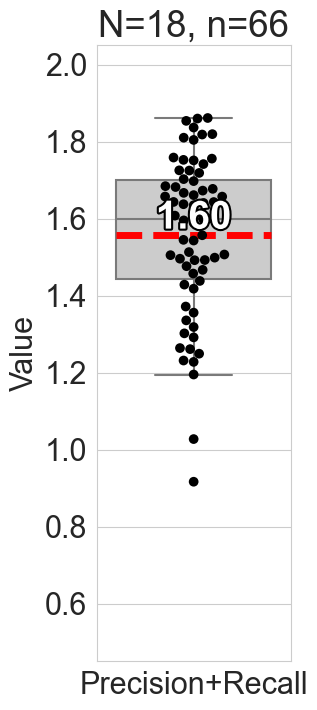

In [41]:
boxplot_full_set_v2(unet_df,
                 figsize=(2.5,8),
                 fontsize=22,
                 swarmsize=7,
                 savename="PrecisionRecall_UNet",
                 title='N=18, n=66',
                 titlewrap=25,
                 xlabel='',
                 ylabel='Value',
                 ylim=(0.45,2.05),
                 colors = ['0.8','0.8'],
                 #colors = ["#6BA3F0"],
                 swarmpalette=["0.0"],
                 median_labels=True,
                 median_color='white',
                 median_outline=True,
                 median_outline_color='0.0',
                 median_fontsize=28,
                 show_means=True,
                 meanline=True,
                 meanprops={"c":"red",
                           "ls":"--",
                           'linewidth':'5'},
                 savefig=False
                )